In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [3]:

plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv("AmesHousing.csv")
print(df.shape)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


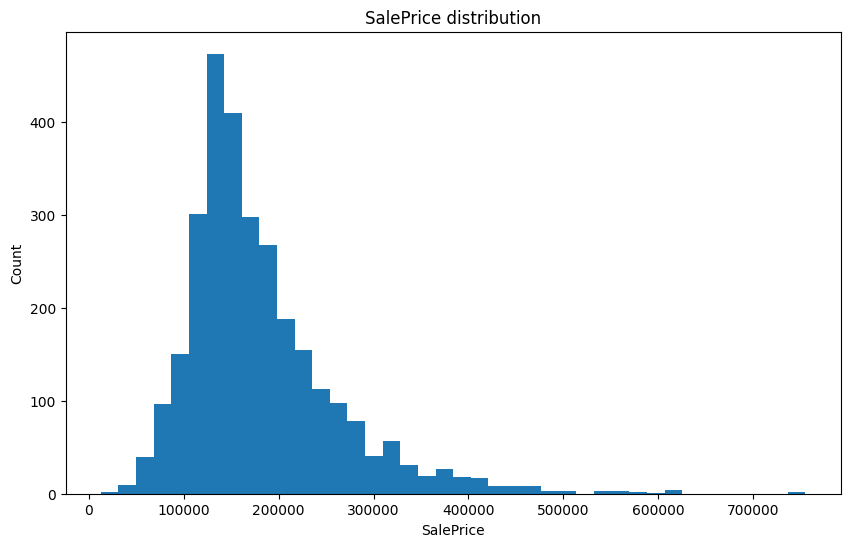

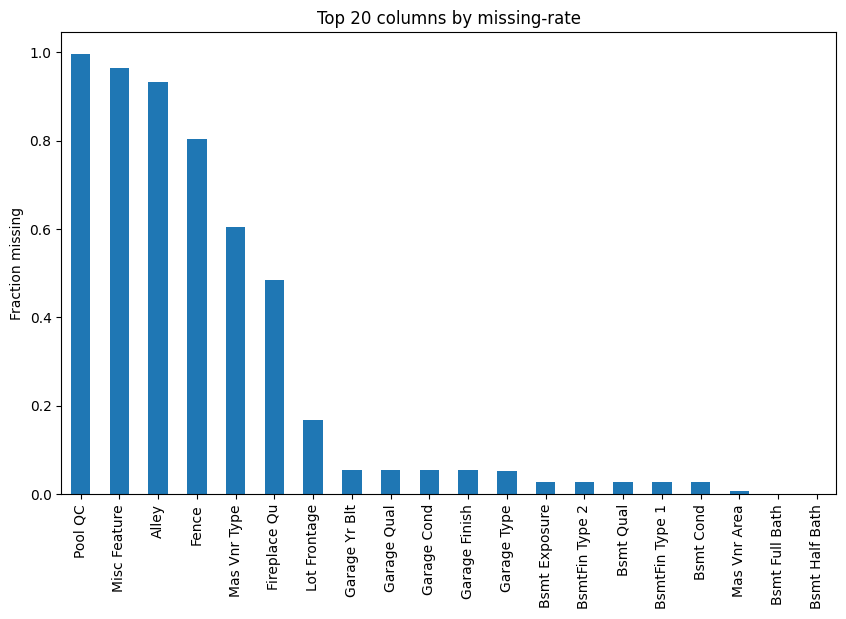

,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


In [4]:
# 2) Target check + quick visuals
assert 'SalePrice' in df.columns, "Target 'SalePrice' not found!"

# Drop obvious IDs (they don't help prediction)
id_cols = [c for c in ['Order','PID'] if c in df.columns]
df = df.drop(columns=id_cols)

# Target distribution
plt.hist(df['SalePrice'].dropna(), bins=40)
plt.title("SalePrice distribution")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

# Missing values (top 20)
na_rate = df.isna().mean().sort_values(ascending=False)
na_rate = na_rate[na_rate>0].head(20)
na_rate.plot(kind='bar')
plt.title("Top 20 columns by missing-rate")
plt.ylabel("Fraction missing")
plt.show()

df['SalePrice'].describe()

In [5]:
# 3) Train/Test split + preprocessors
y = df['SalePrice'].values
X = df.drop(columns=['SalePrice'])

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

len(num_cols), len(cat_cols), X_train.shape, X_test.shape

(36, 43, (2344, 79), (586, 79))

In [8]:
#Linear Regression
pipe_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LinearRegression())
])

pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)

def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

m_lr = metrics(y_test, pred_lr)
m_lr

{'R2': 0.8906061484542793,
 'RMSE': 877070448.1144238,
 'MAE': 16007.378340863734}

In [9]:
#Ridge with cross-validated alpha
alphas_ridge = np.logspace(-3, 3, 50)  # 0.001 to 1000
ridge_cv = RidgeCV(alphas=alphas_ridge, store_cv_values=False)

pipe_ridge = Pipeline(steps=[
    ("prep", preprocess),
    ("model", ridge_cv)
])

pipe_ridge.fit(X_train, y_train)
pred_ridge = pipe_ridge.predict(X_test)
m_ridge = metrics(y_test, pred_ridge)

best_alpha_ridge = pipe_ridge.named_steps["model"].alpha_
print("Best Ridge alpha:", best_alpha_ridge)
m_ridge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


Best Ridge alpha: 1.5264179671752334


{'R2': 0.895308491109735, 'RMSE': 839369190.4867558, 'MAE': 16336.9569491119}

In [12]:
#Lasso with cross-validated alpha
alphas_lasso = np.logspace(-3, 1, 50)  # 0.001 to 10 usually enough for Lasso
lasso_cv = LassoCV(alphas=alphas_lasso, max_iter=20000, cv=5, n_jobs=-1, random_state=42)

pipe_lasso = Pipeline(steps=[
    ("prep", preprocess),
    ("model", lasso_cv)
])

pipe_lasso.fit(X_train, y_train)
pred_lasso = pipe_lasso.predict(X_test)
m_lasso = metrics(y_test, pred_lasso)

best_alpha_lasso = pipe_lasso.named_steps["model"].alpha_
print("Best Lasso alpha:", best_alpha_lasso)
m_lasso

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3635782785.0654297, tolerance: 1081630771.4729667
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13255005810.250732, tolerance: 1081630771.4729667
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3377823351.9405518, tolerance: 1103990068.1049752
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Converge

Best Lasso alpha: 10.0


{'R2': 0.8966623542980566,
 'RMSE': 828514527.4824957,
 'MAE': 15574.906970107311}

In [13]:
# 7) Metric comparison
res_df = pd.DataFrame([
    {"Model":"Linear", **m_lr},
    {"Model":"Ridge", **m_ridge},
    {"Model":"Lasso", **m_lasso},
])
res_df

,Model,R2,RMSE,MAE
0,Linear,0.890606,8.770704e+08,16007.378341
1,Ridge,0.895308,8.393692e+08,16336.956949
2,Lasso,0.896662,8.285145e+08,15574.906970


In [15]:
print("Linear train R²:", pipe_lr.score(X_train, y_train))
print("Linear test R²:", pipe_lr.score(X_test, y_test))

print("Ridge train R²:", pipe_ridge.score(X_train, y_train))
print("Ridge test R²:", pipe_ridge.score(X_test, y_test))

print("Lasso train R²:", pipe_lasso.score(X_train, y_train))
print("Lasso test R²:", pipe_lasso.score(X_test, y_test))

Linear train R²: 0.9394057771448325
Linear test R²: 0.8906061484542793
Ridge train R²: 0.9263997665576087
Ridge test R²: 0.895308491109735
Lasso train R²: 0.9379192270015808
Lasso test R²: 0.8966623542980566


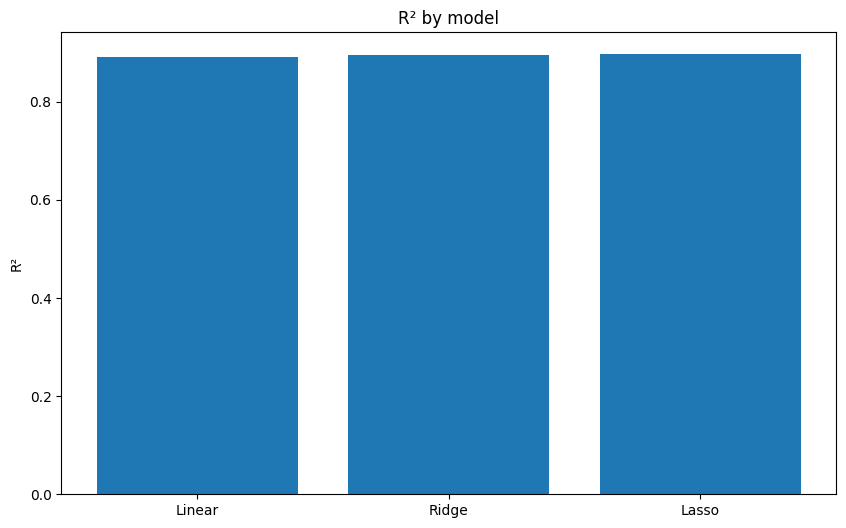

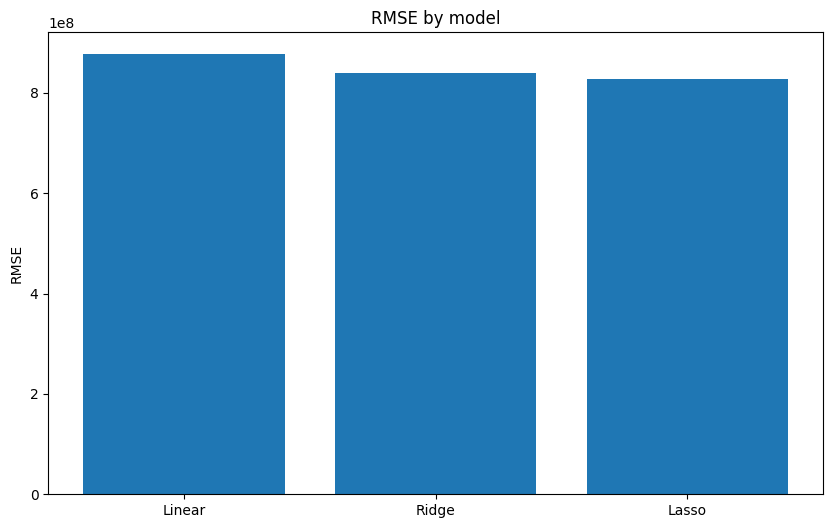

In [16]:
# Bar chart for R2 and RMSE
fig, ax = plt.subplots()
ax.bar(res_df["Model"], res_df["R2"])
ax.set_title("R² by model")
ax.set_ylabel("R²")
plt.show()

fig, ax = plt.subplots()
ax.bar(res_df["Model"], res_df["RMSE"])
ax.set_title("RMSE by model")
ax.set_ylabel("RMSE")
plt.show()